# TUTORIAL: SEGMENTACIÓN DE INSTANCIAS CON YOLO 11

En este tutorial veremos cómo usar un set de imágenes propio para afinar el modelo YOLO11 (la versión más reciente de Ultralytics) para realizar una tarea de segmentación de instancias de objetos.

Contenido:

1. ¿Qué es YOLO11?
2. Tipos de segmentación (de instancias vs. semántica)
3. Objetivo del tutorial
4. Preparación del dataset
5. Afinación de YOLO11 (segmentación de instancias) con el dataset
6. Generación de predicciones con el modelo afinado

## 1. ¿Qué es YOLO11?

YOLO11 es la última versión del modelo de detección de objetos de Ultralytics que permite realizar tareas como la detección de objetos, segmentación de instancias y la estimación de poses entre otras:

![](https://raw.githubusercontent.com/ultralytics/assets/main/im/banner-tasks.png)

Esta nueva versión ofrece cinco tamaños de modelo: Nano, Small, Medium, Large y X.

## 2. Tipos de segmentación (de instancias vs. semántica)

![](https://corrosionsegmenter.com/static/Homepage_photos/Semantic_vs_instance.jpg)

- Segmentación de instancias: la idea es **identificar y delinear cada objeto en una imagen** (ejemplo: fondo, persona 1, persona 2,...)
- Segmentación semántica: categoriza los pixeles de una imagen en diferentes clases (ejemplo: fondo, persona)

## 3. Objetivo del tutorial

En este tutorial veremos cómo afinar el modelo YOLO11 para realizar segmentación de instancias usando un dataset propio.

En el caso de YOLO11 la salida (predicción) hecha por el modelo contendrá tres elementos:

- Las máscaras (contornos) the cada objeto
- La categoría de cada objeto
- Las probabilidades asociadas a cada objeto

![](https://cdn.prod.website-files.com/6479eab6eb2ed5e597810e9e/6729fecc79bc58a68880f373_6729fd101d9e509019292e2a_Segmentation_Fig%25201.png)

## 4. Preparación del dataset

Al igual que ocurrió con el tutorial de detección de objetos, según la documentación de Ultralytics, el set de imágenes debe estar estructurado de esta manera:

![](https://github.com/ultralytics/docs/releases/download/0/two-persons-tie-2.avif)

Además, los modelos disponibles son los siguientes:

![](https://drive.google.com/uc?export=view&id=1SrOta15xyyMYYX7w_8Ey9GtVYDRQY0Jo)

En este caso usaremos el modelo más pequeño (YOLO11n-seg) con 2.9 millones de parámetros.

Al igual que con la detección de objetos, en este caso se debe garantizar que la dimensión más grande a usar en las imágenes sea de 640 pixeles.

Estos son los pasos para tener disponible el set de datos desde Google Colab:

1. Primero debemos crear la carpeta "datasets" en el directorio "content" de Google Colab
2. Ahora descargamos el set de datos desde [este enlace](https://drive.google.com/file/d/1seDEH32VjgCshHJsG2i8L-sG6PNDeT7Y/view?usp=sharing).
3. Una vez descargado el archivo "dataset_masas_agua.zip" lo llevamos a la carpeta "datasets" de Google Colab
4. Ahora descomprimimos el archivo .zip:

In [ ]:
!unzip "datasets/dataset_masas_agua.zip" -d datasets/masas_agua

Archive:  datasets/dataset_masas_agua.zip
   creating: datasets/masas_agua/images/
  inflating: datasets/masas_agua/images/.DS_Store  
   creating: datasets/masas_agua/images/test/
  inflating: datasets/masas_agua/images/test/QQ20230316-095339-2x_png_jpg.rf.9c1b242e2c151b01fd0302be53c138f0.jpg  
  inflating: datasets/masas_agua/images/test/10247_jpeg_jpg.rf.778864c6ddc550f805d3590d1017579a.jpg  
  inflating: datasets/masas_agua/images/test/10212_jpeg_jpg.rf.ba598521f0e5a363c4e18d70a0631277.jpg  
  inflating: datasets/masas_agua/images/test/WechatIMG62_jpeg_jpg.rf.d911ffa6e33de3d291ed9c26a613e1a5.jpg  
  inflating: datasets/masas_agua/images/test/10237_jpeg_jpg.rf.2cec131af43faf4232004bcd2c65d3c8.jpg  
  inflating: datasets/masas_agua/images/test/QQ20230316-095323-2x_png_jpg.rf.6bfc38a2bf59e640cbcfd722306793fb.jpg  
  inflating: datasets/masas_agua/images/test/WechatIMG60_jpeg_jpg.rf.a168360c8e8cba808e1273913a2e4b45.jpg  
  inflating: datasets/masas_agua/images/test/10204_jpeg_jpg.rf.84

Y finalmente podemos eliminar el archivo .zip.

Verifiquemos que la estructura del set de datos es la especificada en la documentación de Ultralytics.

En total tendremos:

- 1.800 imágenes de entrenamiento
- 386 imágenes de validación
- 385 imágenes de prueba

Además, por cada imagen tendremos una etiqueta correspondiente. Esta etiqueta es un archivo que contiene el mismo nombre de la imagen y ubicado en la carpeta "labels".

Acá un ejemplo de uno de estos archivos:


```
0 0.019479016674635 0.7572807397597392 0.9565207544322961 0.4137902387902038 0.06623552144808464 0.5769703296820713 0.12919378369042364 0.9204608306516067
0 0.6629320682248917 0.4815050417651926 0.6532378519418947 0.4056399442394203 0.13368551666520592 0.4720295340873393 0.14337973294820294 0.5478946316131116
0 0.985838495598216 0.3716796759791363 0.9691616340673997 0.3158526156542626 0.6188318501402568 0.42050439675602724 0.6355087116710729 0.476331457080901
0 0.13512469227236049 0.476852626613488 0.13159425851753692 0.4626935325068411 0.001299764049788199 0.49582937718391823 0.0022306697050353597 0.5099884712905651
```

En este caso:

- Cada fila corresponde a un objeto presente en la imagen. En el ejemplo anterior total tendremos 4 filas y por tanto un total de 4 objetos
- Por cada objeto tendremos esta información: `class <x1> <y1> <x2> <y2> ... <xn> <yn>`:

![](https://drive.google.com/uc?export=view&id=1StKbwU27BVDQk9qqFcCAszSJdmPx0N_-)

Como en este caso queremos afinar el modelo para que detecte un solo tipo de objeto (0: agua) por tanto tendremos en todos los casos la categoría 0.

Ahora debemos crear el archivo .YAML que es como el índice del dataset y que debe seguir esta estructura:

```
path: ../datasets/coco8 # dataset root dir
train: images/train # train images (relative to 'path') 4 images
val: images/val # val images (relative to 'path') 4 images
test: # test images (optional)

# Classes (80 COCO classes)
names:
    0: person
    1: bicycle
    2: car
    # ...
    77: teddy bear
    78: hair drier
    79: toothbrush
```

Usemos el módulo "yaml" para crear este archivo:


In [ ]:
import yaml

data = {
    'path': 'datasets/masas_agua',
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'names': {
        0: 'agua'
    }
}

with open('datasets/masas_agua/data.yaml', 'w') as file:
    yaml.dump(data, file,
              default_flow_style=False,
              sort_keys=False)


Y listo. Ya tenemos listo el set de datos y ya podemos comenzar a hacer la afinación.

## 5. Afinación de YOLO11 (segmentación de instancias) con el dataset

Para poder acceder al modelo pre-entrenado debemos comenzar instalando la librería "ultralytics":

In [ ]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 37.6 MB/s eta 0:00:00m eta 0:00:010:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 783.6/783.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 MB 35.7 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 24.7 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 29.2 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 30.3 MB/s eta 0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 13.0 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 26.3 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 28.3 MB/s eta

Y tan sólo debemos llevar a cabo estos dos pasos para afinar el modelo:

1. Importar el modelo pre-entrenado
2. Usar el método "train" para realizar la afinación

Por defecto en cada iteración de entrenamiento se almacenarán los pesos del modelo afinado en la carpeta "runs". Se recomienda realizar la afinación usando la GPU (aunque con la CPU es posible, simplemente se requerirá más tiempo):

In [ ]:
from ultralytics import YOLO

# 1. Cargar el modelo (nano, el más pequeño)
model = YOLO("yolo11n-seg.pt")

# Afinar el modelo
results = model.train(data="datasets/masas_agua/data.yaml",
                      epochs=40, # Número de iteraciones
                      imgsz=640, # Tamaño de las imágenes (máxima dimensión)
                      plots=True, # Guardar gráficos de entrenamiento
                      )

Ultralytics 8.3.234 🚀 Python-3.13.5 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 3060, 12044MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets/masas_agua/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0

Al realizar la afinación veremos impresas en pantalla varias métricas de las cuáles las más importantes son:

- "seg_loss": mide la diferencia entre la máscara de segmentación de referencia y la predicha por el modelo.
- "box_loss": mide el error en la ubicación y tamaño de los "bounding boxes" predichos en comparación con los de referencia. Se calcula como 1 - IntersectionOverUnion.
- "cls_loss": es el error en la clasificación del objeto dentro del "bounding box". Se calcula como la entropía cruzada
- "mAP": la precisión media que mide qué tan buenas detecciones genera el modelo (entre más cercano a 1 sea este valor mejor será el desempeño).

Después de unos minutos tendremos el modelo ya afinado. Este quedará almacenado en la carpeta `../content/runs/segment/train/weights/best.pt'`.

Podemos generar algunos gráficos del proceso de entrenamiento y validación para verificar que no haya "overfitting".

Por ejemplo grafiquemos las pérdidas para entrenamiento y validación:

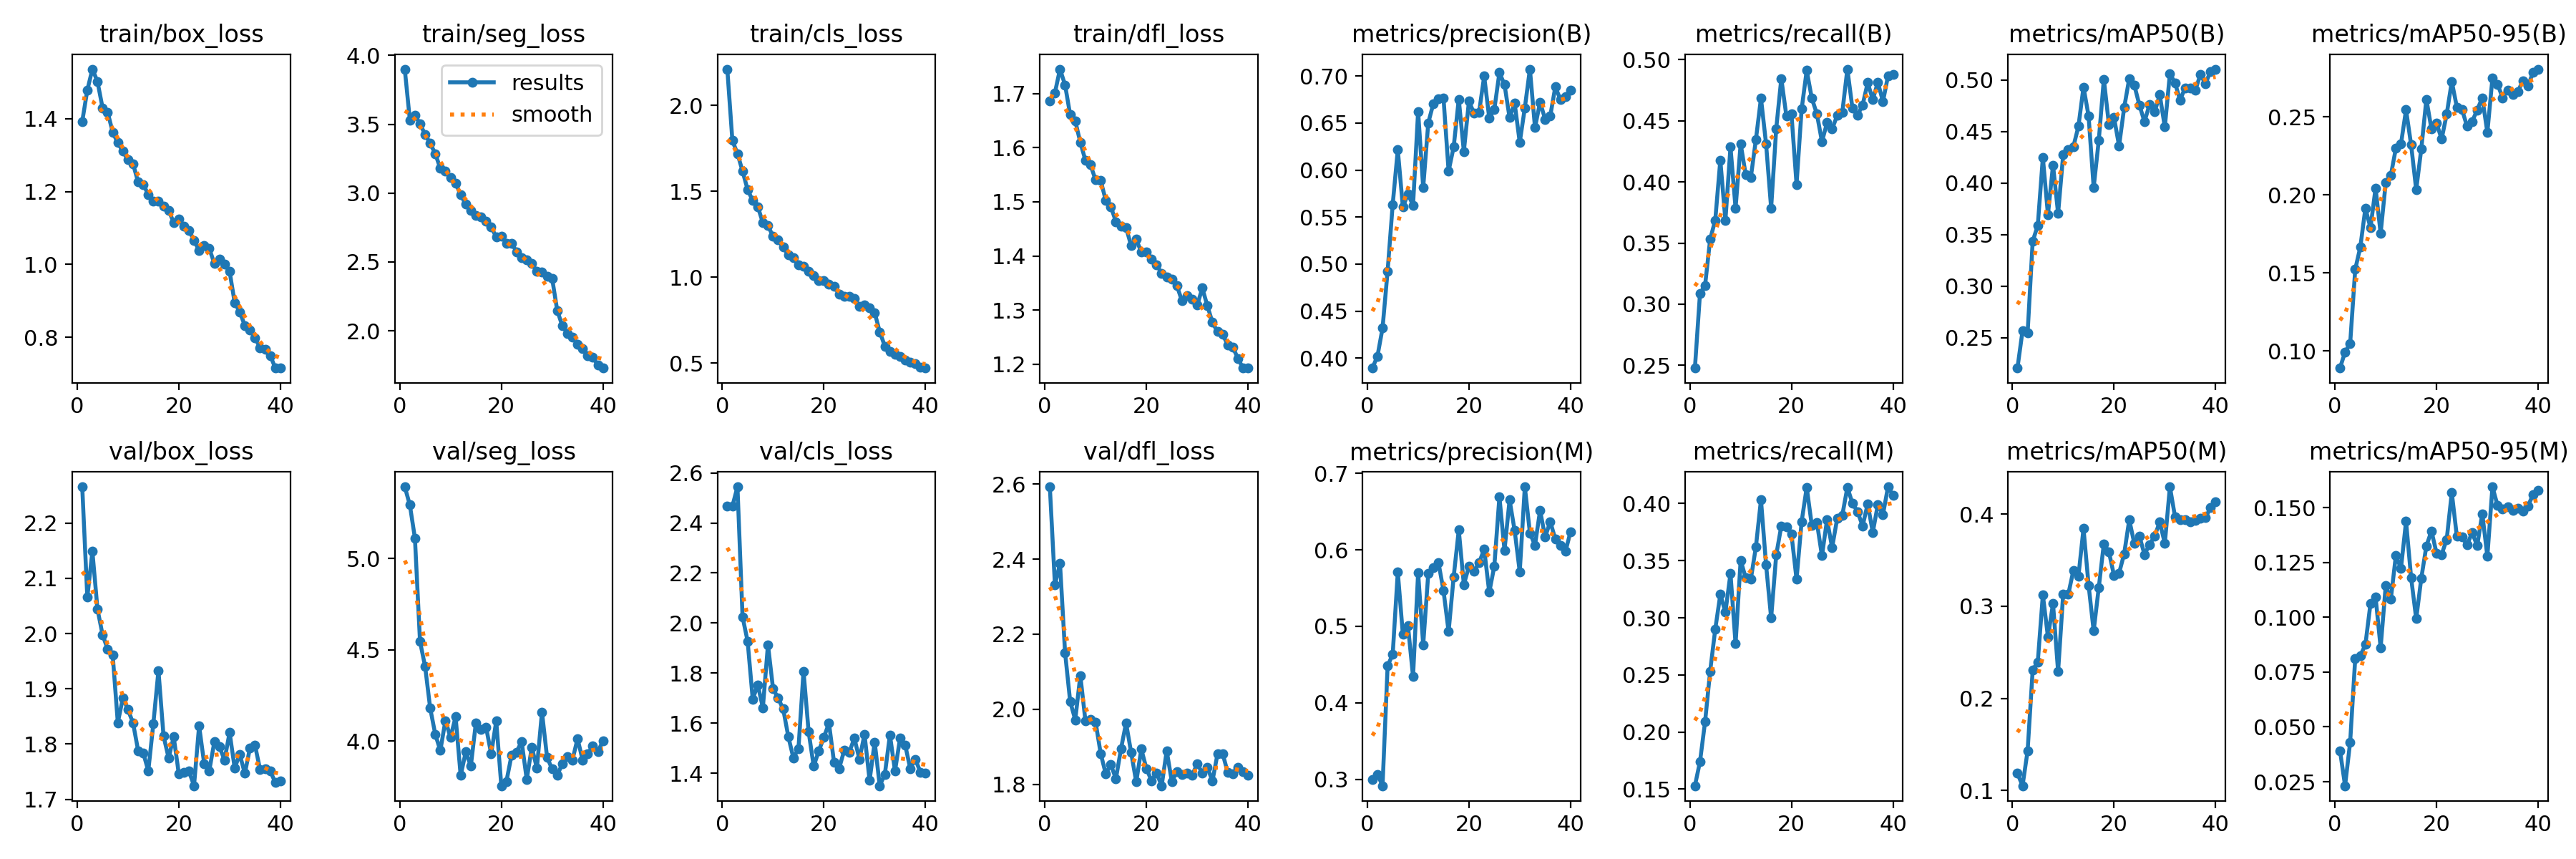

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename='runs/segment/train3/results.png', width=800)

Y al observar estas gráficas vemos que convergen a valores muy cercanos tanto en entrenamiento como en validación y por tanto podemos concluir que el modelo afinado generaliza bastante bien.

## 5. Generación de predicciones con el modelo afinado

Y por último, podemos usar el set de prueba (disponible en la carpeta `../datasets/masas_agua/images/test`) para generar predicciones sobre nuevos datos usando el modelo afinado.

Comencemos cargando el modelo afinado:

In [ ]:
model = YOLO('runs/segment/train3/weights/best.pt')

Y ahora generemos predicciones sobre la totalidad del set de prueba:

In [ ]:
preds = model('datasets/masas_agua/images/test')


image 1/385 /home/ciabd10/Descargas/MIA/Actividad 1/datasets/masas_agua/images/test/10203_jpg.rf.fc4549fe571e01ad5c67993746ac448f.jpg: 640x640 4 aguas, 5.1ms
image 2/385 /home/ciabd10/Descargas/MIA/Actividad 1/datasets/masas_agua/images/test/10204_jpeg_jpg.rf.24d5197b0a496e6320336dfec8e98705.jpg: 640x640 1 agua, 5.2ms
image 3/385 /home/ciabd10/Descargas/MIA/Actividad 1/datasets/masas_agua/images/test/10204_jpeg_jpg.rf.2a7318fbfa3c00c4187fffe5d7d66184.jpg: 640x640 1 agua, 6.8ms
image 4/385 /home/ciabd10/Descargas/MIA/Actividad 1/datasets/masas_agua/images/test/10204_jpeg_jpg.rf.4085a3892fa0126ed10da52d2c20a761.jpg: 640x640 1 agua, 5.1ms
image 5/385 /home/ciabd10/Descargas/MIA/Actividad 1/datasets/masas_agua/images/test/10204_jpeg_jpg.rf.52d7c797a818d8b80b593c467d867c93.jpg: 640x640 1 agua, 6.2ms
image 6/385 /home/ciabd10/Descargas/MIA/Actividad 1/datasets/masas_agua/images/test/10204_jpeg_jpg.rf.8449f69fc2666060a6954f0ac5342fd1.jpg: 640x640 1 agua, 5.1ms
image 7/385 /home/ciabd10/Desca

Y para ver las predicciones generadas modemos simplemente acceder a una predicción individual y usar el método "show" para dibujar la imagen junto con la máscara de segmentación predicha:

In [ ]:
# Imágenes con buenas segmentaciones: 13, 150, 134
preds[20].show()